# Netflix Titles Analysis & Content-Based Recommender
### Exploratory analysis of Netflix's content catalog, plus a recommendation system

**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) — ~8,800 titles available on Netflix as of 2021, with metadata on type, cast, director, country, genre, rating, and release year.

**Goals of this notebook:**
1. Clean and prepare the dataset (including fixing a known data-shift bug)
2. Explore content trends: growth over time, genres, countries, ratings, durations
3. Analyze text patterns in titles and descriptions
4. Build a content-based recommendation system ("if you liked X, you might like Y")

**Author's note:** This notebook is structured the way a real content-analytics workflow would be: data cleaning → exploration → insight → a working recommender that operationalizes the content similarity findings.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)

DATA_DIR = "data/"


In [2]:
df = pd.read_csv(DATA_DIR + "netflix_titles.csv")
print(f"Shape: {df.shape}")
df.head(3)


Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


### 1.1 Data Quality Check

Let's check for missing values and a known issue in this dataset: a handful of rows have their columns shifted, causing duration values (e.g. `"74 min"`) to appear in the `rating` column.

In [3]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Data types:")
print(df.dtypes)


Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Data types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [4]:
# Known bug: a few rows have duration values leaked into the rating column
shifted_rows = df[df["rating"].isin(["74 min", "84 min", "66 min"])]
print(f"Rows with shifted columns: {len(shifted_rows)}")
shifted_rows[["show_id", "title", "rating", "duration"]]


Rows with shifted columns: 3


,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [5]:
# Fix: move the leaked duration value into the duration column, and set rating to missing (unknown)
shift_mask = df["rating"].str.contains("min", na=False)
df.loc[shift_mask, "duration"] = df.loc[shift_mask, "rating"]
df.loc[shift_mask, "rating"] = np.nan

print(f"Fixed {shift_mask.sum()} rows.")
print(df.loc[shift_mask, ["title", "rating", "duration"]])


Fixed 3 rows.
                                     title rating duration
5541                       Louis C.K. 2017    NaN   74 min
5794                 Louis C.K.: Hilarious    NaN   84 min
5813  Louis C.K.: Live at the Comedy Store    NaN   66 min


## 2. Data Cleaning & Feature Engineering

In [6]:
# Parse date_added into a real datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# Split duration into numeric value + unit (movies = minutes, TV shows = seasons)
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([a-zA-Z]+)")

# Fill text fields used for analysis/recommender with empty string instead of NaN
for col in ["director", "cast", "country", "listed_in", "description"]:
    df[col] = df[col].fillna("")

print(f"Year added range: {df['year_added'].min():.0f} - {df['year_added'].max():.0f}")
print(f"Release year range: {df['release_year'].min()} - {df['release_year'].max()}")
df[["title", "type", "duration", "duration_value", "duration_unit"]].head()


Year added range: 2008 - 2021
Release year range: 1925 - 2021


,title,type,duration,duration_value,duration_unit
0,Dick Johnson Is Dead,Movie,90 min,90.0,min
1,Blood & Water,TV Show,2 Seasons,2.0,Seasons
2,Ganglands,TV Show,1 Season,1.0,Season
3,Jailbirds New Orleans,TV Show,1 Season,1.0,Season
4,Kota Factory,TV Show,2 Seasons,2.0,Seasons


## 3. Catalog Overview: Movies vs. TV Shows

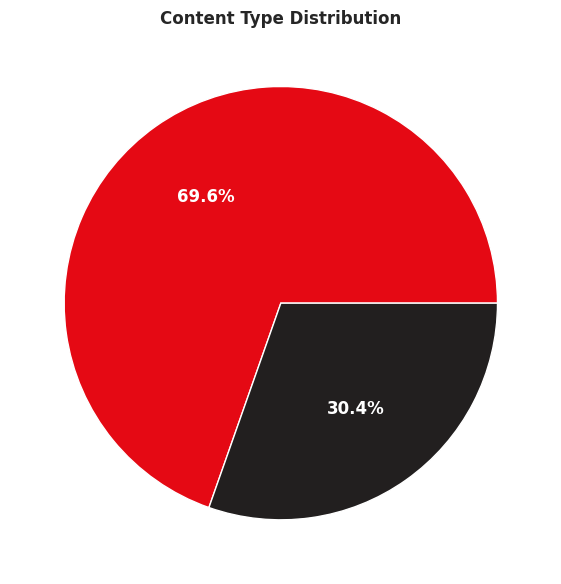

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [7]:
type_counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
       colors=["#e50914", "#221f1f"], textprops={"color": "white", "fontweight": "bold"})
ax.set_title("Content Type Distribution")
plt.tight_layout()
plt.show()

print(type_counts)


**Insight:** Movies make up roughly 70% of the catalog, with TV Shows at 30%. This is a useful baseline before breaking down trends further.

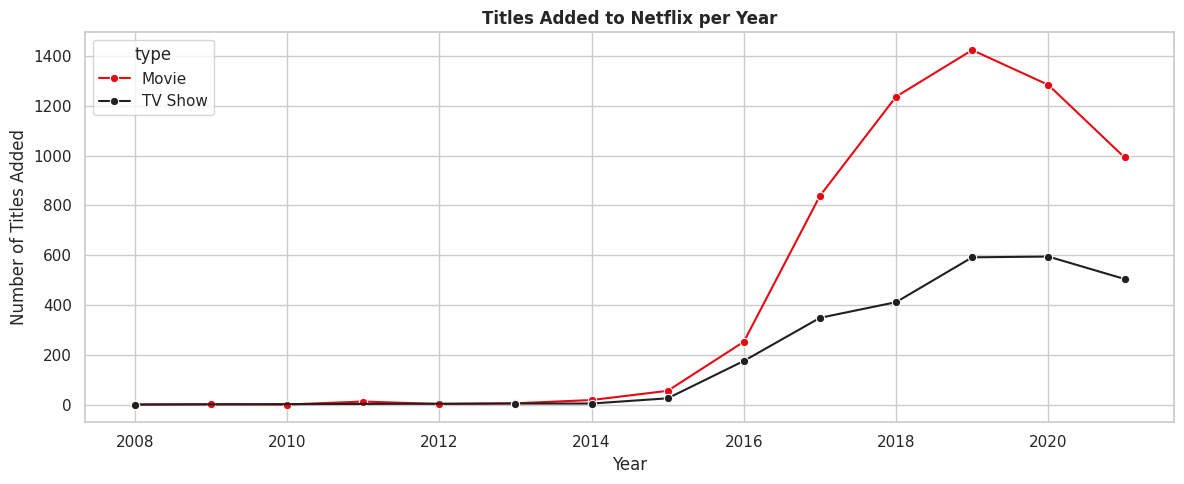

In [8]:
# Growth over time: titles added per year, by type
added_by_year = df.dropna(subset=["year_added"]).groupby(["year_added", "type"]).size().reset_index(name="count")
added_by_year = added_by_year[added_by_year["year_added"] <= 2021]  # dataset trails off after 2021

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=added_by_year, x="year_added", y="count", hue="type", marker="o",
             palette=["#e50914", "#221f1f"], ax=ax)
ax.set_title("Titles Added to Netflix per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()


**Insight:** Netflix's catalog additions accelerated sharply from 2016 onward, peaking around 2019, then declining — consistent with Netflix's well-documented pivot from aggressive content licensing/acquisition toward a slower pace with a growing emphasis on original productions.

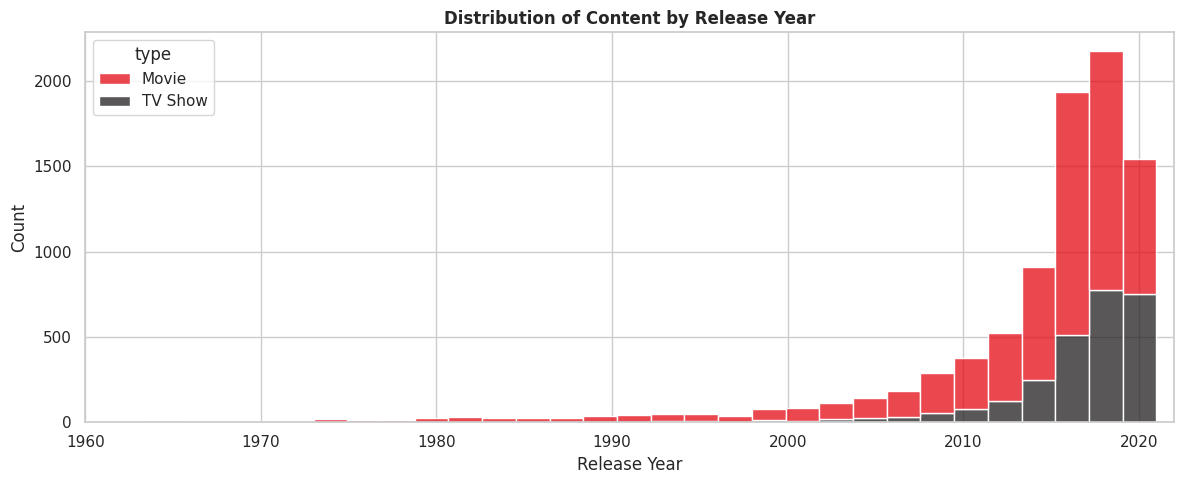

In [9]:
# Release year distribution - how old is the content actually?
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df, x="release_year", hue="type", bins=50, palette=["#e50914", "#221f1f"], ax=ax, multiple="stack")
ax.set_title("Distribution of Content by Release Year")
ax.set_xlabel("Release Year")
ax.set_xlim(1960, 2022)
plt.tight_layout()
plt.show()


**Insight:** The vast majority of content (movies especially) was released in the last decade, even though titles were *added* to Netflix over a longer window — confirming Netflix's catalog skews heavily toward recent content rather than classic film/TV libraries.

## 4. Genres & Categories

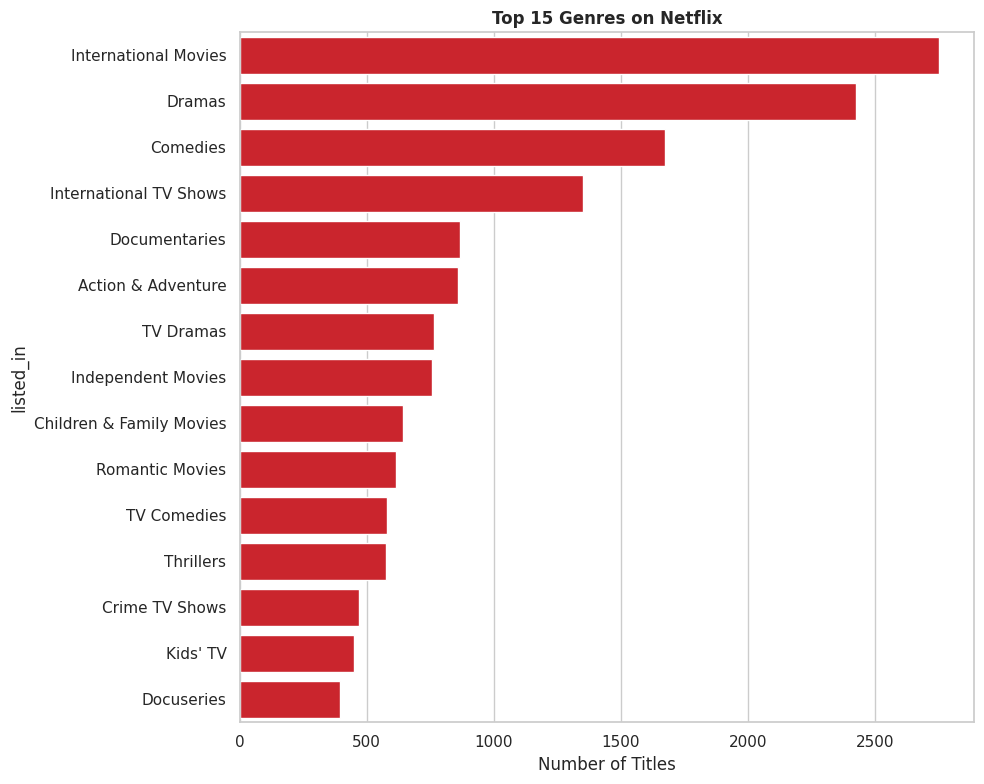

In [10]:
genre_counts = df["listed_in"].str.split(", ").explode().value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=genre_counts.head(15).values, y=genre_counts.head(15).index, ax=ax, color="#e50914")
ax.set_title("Top 15 Genres on Netflix")
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.show()


**Insight:** International Movies, Dramas, and Comedies dominate the catalog. This reflects Netflix's strategy of localizing content for global markets rather than relying purely on US-centric programming.

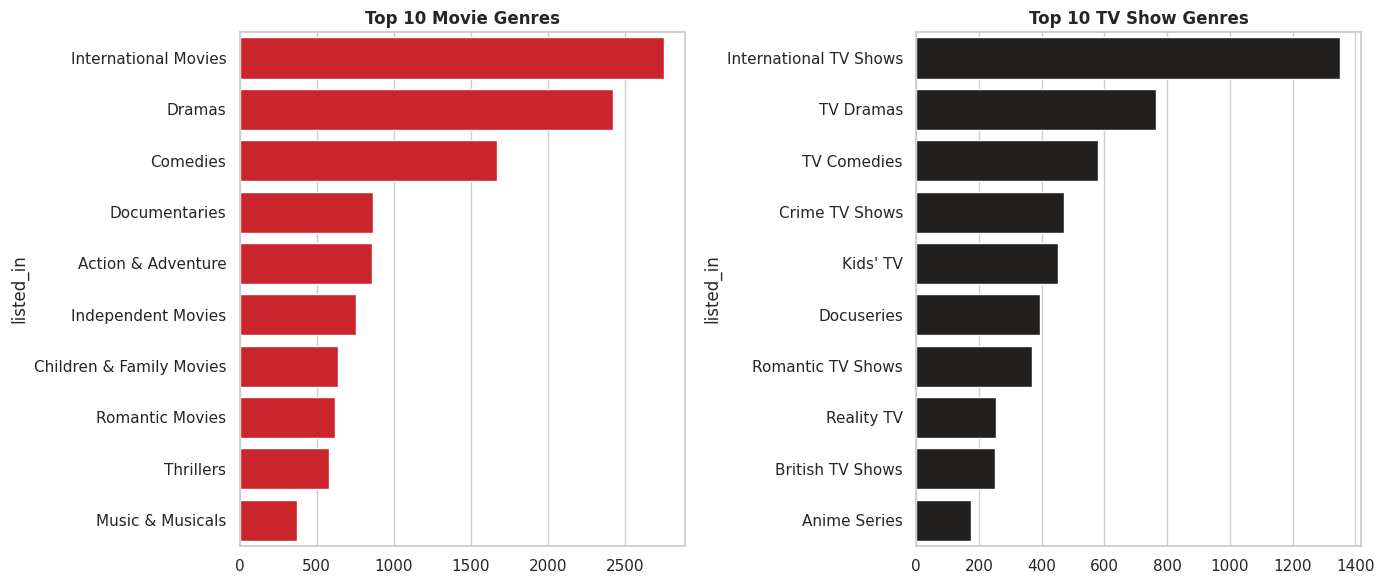

In [11]:
# genre breakdown by content type
movie_genres = df[df["type"] == "Movie"]["listed_in"].str.split(", ").explode().value_counts().head(10)
tv_genres = df[df["type"] == "TV Show"]["listed_in"].str.split(", ").explode().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=movie_genres.values, y=movie_genres.index, ax=axes[0], color="#e50914")
axes[0].set_title("Top 10 Movie Genres")
sns.barplot(x=tv_genres.values, y=tv_genres.index, ax=axes[1], color="#221f1f")
axes[1].set_title("Top 10 TV Show Genres")
plt.tight_layout()
plt.show()


## 5. Geographic Distribution

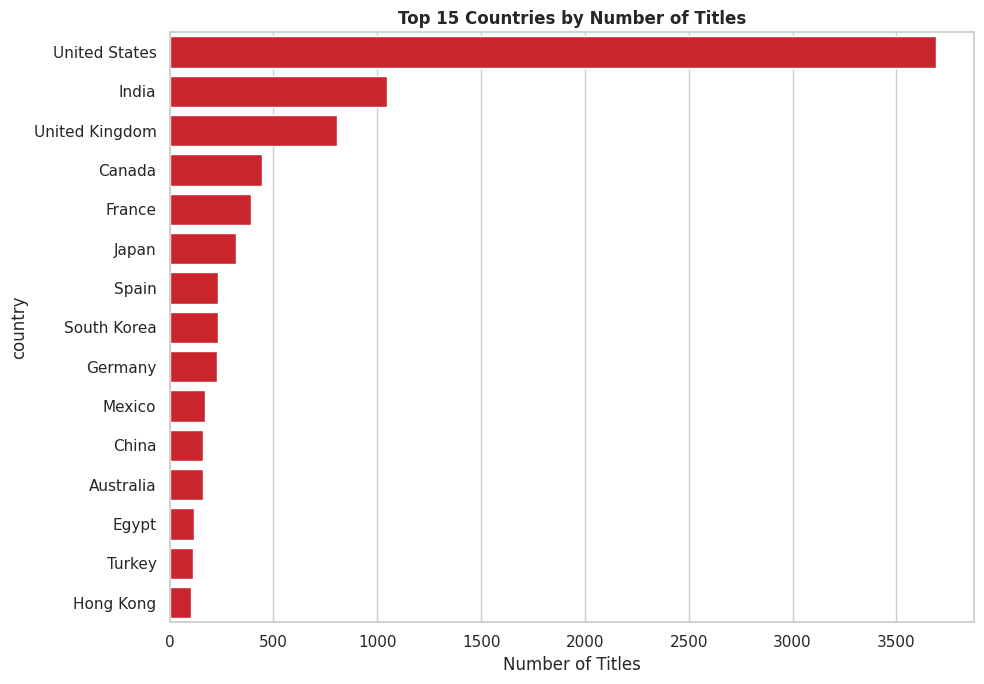

In [12]:
country_counts = df["country"].str.split(", ").explode()
country_counts = country_counts[country_counts != ""].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=country_counts.head(15).values, y=country_counts.head(15).index, ax=ax, color="#e50914")
ax.set_title("Top 15 Countries by Number of Titles")
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.show()


**Insight:** The United States leads by a wide margin, but India, the UK, and a strong mix of other countries (South Korea, Japan, Spain) show Netflix's genuinely global content footprint — particularly India's strong second-place position, reflecting major investment in Bollywood and regional Indian content.

## 6. Ratings & Audience

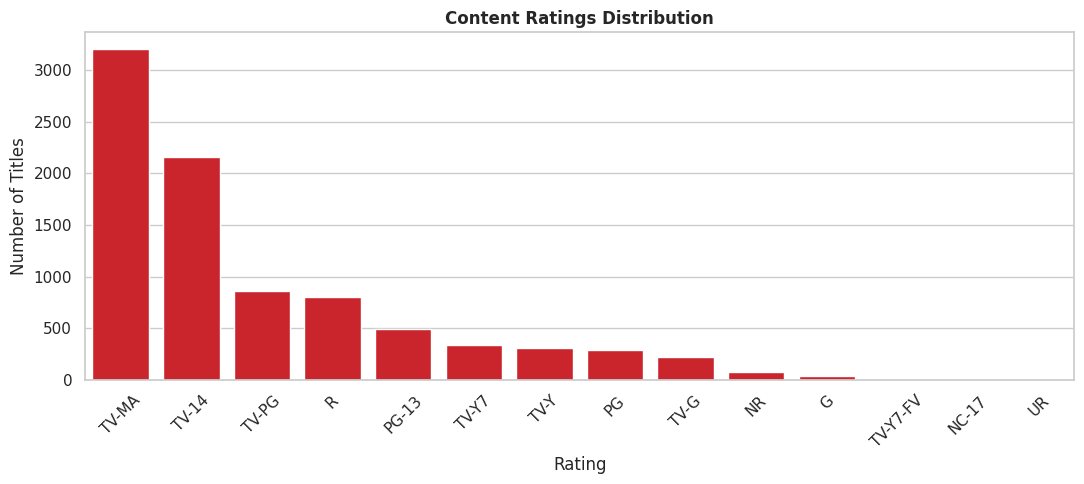

In [13]:
rating_counts = df["rating"].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax, color="#e50914")
ax.set_title("Content Ratings Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** TV-MA (mature audiences) is the single largest rating category, followed by TV-14. Combined with the TV-Y/TV-Y7/G/PG family-friendly ratings being a clear minority, this confirms Netflix's catalog leans toward adult and teen audiences rather than young children's programming.

## 7. Text Analysis: What Are Netflix Titles About?

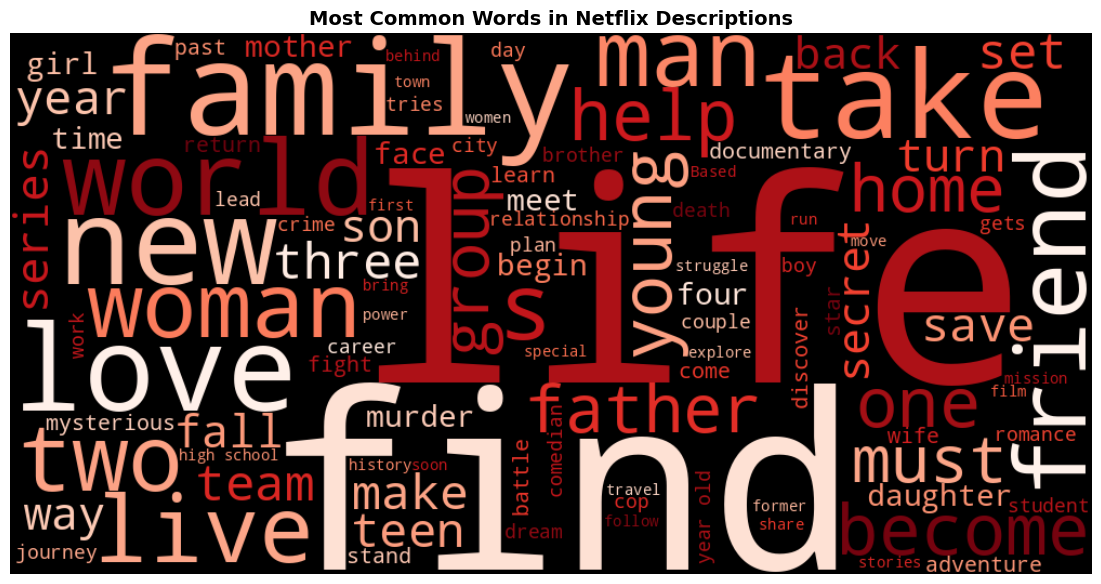

In [14]:
all_descriptions = " ".join(df["description"].tolist())

wordcloud = WordCloud(width=1000, height=500, background_color="black",
                       colormap="Reds", max_words=100, stopwords=None).generate(all_descriptions)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Most Common Words in Netflix Descriptions", color="black", fontsize=14)
plt.tight_layout()
plt.show()


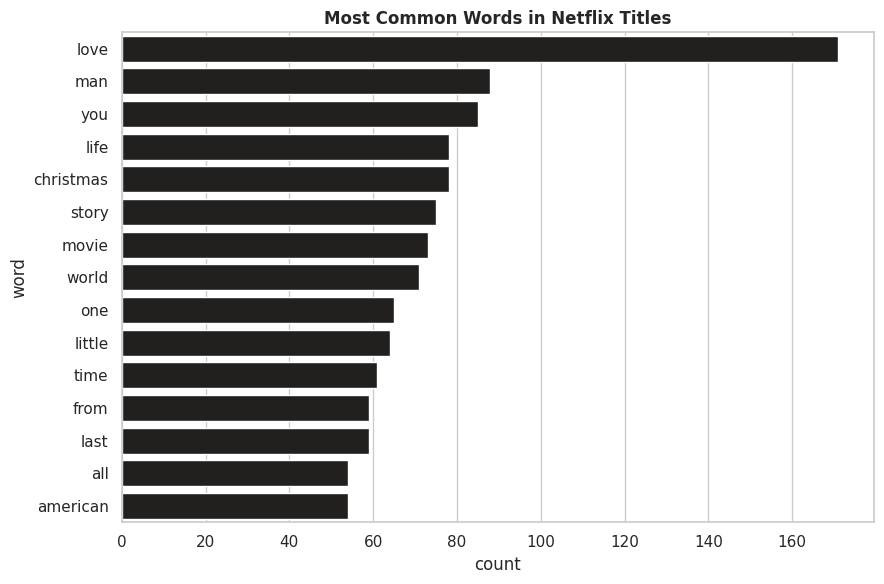

In [15]:
# Most common words in titles themselves (after removing common stopwords)
import re

stopwords_basic = set(["the", "a", "an", "of", "and", "in", "to", "is", "for", "on", "with", "part", "season"])

def tokenize(text):
    words = re.findall(r"[a-z']+", text.lower())
    return [w for w in words if w not in stopwords_basic and len(w) > 2]

title_words = Counter()
for t in df["title"]:
    title_words.update(tokenize(t))

top_title_words = pd.DataFrame(title_words.most_common(15), columns=["word", "count"])

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_title_words, y="word", x="count", ax=ax, color="#221f1f")
ax.set_title("Most Common Words in Netflix Titles")
plt.tight_layout()
plt.show()


**Insight:** Words like "love," "world," "man," and "christmas" recur frequently — "christmas" in particular stands out, reflecting Netflix's well-known strategy of producing a high volume of holiday-themed original movies.

## 8. Content-Based Recommendation System

We'll build a simple but effective content-based recommender: given a title someone enjoyed, suggest similar titles based on **genre, plot description, director, and cast** — the same general approach used by real recommendation engines for "More Like This" features.

**Approach:**
1. Combine genre, description, director, and lead cast into a single text "soup" per title
2. Convert this text into TF-IDF vectors (numerical representations weighing meaningful words higher than common ones)
3. Compute cosine similarity between all titles
4. For any given title, recommend the most similar ones


In [16]:
def get_top_cast(cast_string, n=3):
    if not cast_string:
        return ""
    return " ".join(cast_string.split(", ")[:n])

df["content_soup"] = (
    df["listed_in"] + " " +
    df["description"] + " " +
    df["director"] + " " +
    df["cast"].apply(get_top_cast)
)

tfidf = TfidfVectorizer(stop_words="english", max_features=10000)
tfidf_matrix = tfidf.fit_transform(df["content_soup"])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


TF-IDF matrix shape: (8807, 10000)


In [17]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Similarity matrix shape: {cosine_sim.shape}")

# build a lookup from title -> dataframe index (handle duplicate titles by keeping the first)
title_to_idx = pd.Series(df.index, index=df["title"]).drop_duplicates()


Similarity matrix shape: (8807, 8807)


In [18]:
def recommend(title, n=10):
    """Return the n most similar titles to the given title based on content similarity."""
    if title not in title_to_idx:
        close_matches = df[df["title"].str.contains(title, case=False, na=False)]["title"].head(5).tolist()
        return f"Title not found. Did you mean: {close_matches}?"

    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:n]

    result_idx = [s[0] for s in sim_scores]
    scores = [round(s[1], 3) for s in sim_scores]

    result = df.loc[result_idx, ["title", "type", "listed_in", "release_year"]].copy()
    result["similarity"] = scores
    return result.reset_index(drop=True)

recommend("Breaking Bad")


,title,type,listed_in,release_year,similarity
0,Futmalls.com,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2020,0.206
1,Iron Ladies,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2018,0.204
2,Sparta,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2018,0.196
3,"Have You Ever Fallen in Love, Miss Jiang?",TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2016,0.195
4,The Judgement,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2018,0.190
5,The Underclass,TV Show,"International TV Shows, TV Dramas, Teen TV Shows",2020,0.183
6,Merlí,TV Show,"International TV Shows, TV Dramas, Teen TV Shows",2015,0.182
7,Extracurricular,TV Show,"Crime TV Shows, International TV Shows, Korean...",2020,0.182
8,Servant of the People,TV Show,"International TV Shows, TV Comedies",2015,0.180
9,Refresh Man,TV Show,"International TV Shows, Romantic TV Shows, TV ...",2016,0.177


In [19]:
recommend("The Conjuring")


,title,type,listed_in,release_year,similarity
0,The Conjuring 2,Movie,Horror Movies,2016,0.339
1,Insidious,Movie,"Horror Movies, Thrillers",2010,0.226
2,In the Tall Grass,Movie,"Horror Movies, Thrillers",2019,0.170
3,The Adventures of Sharkboy and Lavagirl,Movie,Children & Family Movies,2005,0.152
4,The Rope Curse 2,Movie,"Horror Movies, International Movies",2020,0.150
5,The Boy in the Striped Pajamas,Movie,"Dramas, Independent Movies, International Movies",2008,0.143
6,Up in the Air,Movie,"Comedies, Dramas, Romantic Movies",2009,0.134
7,All Light Will End,Movie,"Horror Movies, Thrillers",2018,0.132
8,Bates Motel,TV Show,"Crime TV Shows, TV Dramas, TV Horror",2017,0.130
9,Safe House,Movie,Action & Adventure,2012,0.126


In [20]:
recommend("Stranger Things")


,title,type,listed_in,release_year,similarity
0,"Frankenstein’s Monster’s Monster, Frankenstein",Movie,Comedies,2019,0.217
1,How to Make an American Quilt,Movie,"Dramas, Romantic Movies",1995,0.189
2,Manifest,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",2021,0.181
3,Anjaan: Special Crimes Unit,TV Show,"International TV Shows, TV Horror, TV Mysteries",2018,0.181
4,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",2018,0.180
5,The OA,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",2019,0.179
6,Carmen Sandiego,TV Show,"Kids' TV, TV Thrillers",2021,0.175
7,Sakho & Mangane,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2019,0.172
8,"Love, Death & Robots",TV Show,"TV Action & Adventure, TV Horror, TV Sci-Fi & ...",2021,0.169
9,Rowdy Rathore,Movie,"Action & Adventure, Comedies, International Mo...",2012,0.168


**Insight:** Results are mixed in an instructive way. "The Conjuring" produces strong, genre-consistent horror recommendations, and "Stranger Things" surfaces tonally similar sci-fi/mystery titles. "Breaking Bad," on the other hand, returns weaker matches — the TF-IDF approach matches on shared vocabulary in genre tags and descriptions ("Crime TV Shows," "drama"), not deep plot semantics, so it can't distinguish a crime *drama* about addiction from a generic crime thriller.

This is a real, known limitation of pure TF-IDF content-based recommenders, and it's worth stating plainly rather than only showing favorable examples: the model captures **surface-level genre/topic similarity well**, but not nuanced thematic similarity. A production system would likely combine this with collaborative filtering (what similar users actually watched) or with embeddings from a language model, which capture semantic meaning rather than just word overlap. Even with this limitation, the approach has a real practical advantage: it works immediately for brand-new titles with zero viewing history (no cold-start problem), which makes it a reasonable baseline or fallback layer in a hybrid recommender system.

## 9. Summary of Key Findings

| Area | Finding |
|---|---|
| **Catalog mix** | ~70% movies, ~30% TV shows |
| **Growth** | Catalog additions accelerated sharply 2016-2019, then slowed |
| **Content age** | Catalog skews heavily toward content released in the last decade |
| **Genres** | International Movies, Dramas, and Comedies dominate |
| **Geography** | US leads, with India a strong second — reflecting global content investment |
| **Ratings** | TV-MA and TV-14 dominate; family content is a minority |
| **Text patterns** | "Christmas" stands out as a recurring title theme, reflecting Netflix's holiday-content strategy |
| **Recommender** | A TF-IDF + cosine-similarity content-based system works well for genre-distinct titles (e.g. horror, sci-fi) but is limited for genre-overlapping titles, since it matches surface vocabulary rather than deep plot semantics |

### Suggested next steps (if this were a live business)
1. Extend the recommender with collaborative filtering (user viewing history) once behavioral data is available, and blend it with this content-based approach for a hybrid system.
2. Replace TF-IDF with sentence embeddings (e.g. from a transformer model) to capture semantic plot similarity rather than surface word overlap — this would directly address the weaker matches seen above.
3. Investigate the post-2019 slowdown in additions against known industry context (e.g., shift toward originals, COVID-related production delays).
4. Use genre/country gaps to inform content acquisition or production investment decisions.
5. Build a "Christmas content calendar" view given how concentrated holiday programming is in the catalog.
